# Compare ABL profiles

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D
import SANDwake3D_base as sdb

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
import urllib.request
#?solve_ivp

## Set mesh and BC's 

In [3]:
# y-z mesh
dz   = 10
zmin = 2
zmax = zmin + 300
Nz   = int((zmax-zmin)/dz+1)
zvec = np.linspace(zmin,zmax,Nz)

dy   = 10
ymax = 100
Ny   = int((2*ymax)/dy+1)
yvec = np.linspace(-ymax,ymax,Ny)
#Ny=51
#ymax = 125
#yvec = np.linspace(-ymax,ymax,Ny)

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 10.0
dz = 10.0
(21, 31)


In [5]:
turbhh = 90.0
rotorD = 126
turbR  = rotorD*0.5
Cmu, C1eps, C2eps, kfactor = 0.07586245, 1.45631433, 1.92560166, 0.71556826
kfactor = 0.5

# Set parameters
params = {
    'rho' : 1.225,
    'cp'  : 1005,
    'g'   : 9.81,
    'nu'  : 1.5E-5,
    'Cmu' : Cmu,
    'C1eps' : C1eps,
    'C2eps' : C2eps,
    'C3eps' : None, #0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
    'dtau':1,
    
    'ustar' : 0.49, #0.4, #0.575652,
    'qw': 0.1, #0.25,
    'L' : -10000.0, #float('inf'), #-3000,
    'kappa' : 0.42,
    'z0' : 0.005,

    'zlo':zmin,
    'Tw':300,
    'beta':1.0/300.0,
    'Tref':None, #300,
    
    # Extra mesh variables needed for turbine forcing
    'ym':ym,
    'zm':zm,
    
    'XXXturbforcingXX':{'turbx':100.0,     # Turbine x location
                   'turby':0.0,     # Turbine y location
                   'zhh':turbhh,      # Turbine hub-height
                   'turbD':rotorD,   # Turbine diameter
                   'Ct':0.7,
                   'Rdelta':10,
                   'turbfunc':sdb.tanhADM,
                  }
}

# This parameter defines V(z) -- deg per meter
veerpermeter = 0.0 #0.02

In [6]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,params)
    
# Set up veer profile
veerProf = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerProf[i] = veerpermeter*(z-turbhh)

Uprof, Vprof = SANDwake3D.getUVfromUhVeer(UABL, veerProf)

# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, Uprof), np.interp(zbot, zvec, Uprof)
Vtop, Vbot = np.interp(ztop, zvec, Vprof), np.interp(zbot, zvec, Vprof)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  11.389708621134238
alpha =  0.1046759655781315
rotor veer =  0.0


In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*params['Tw']
EPSinit= np.zeros((Ny, Nz))
pinit  = np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = Uprof[iz] #UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = Vprof[iz] #veerV[iz]
    Winit[:, iz] = 0.0
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,params)*kfactor #SANDwake3D.init_k_ABL(z,params)*np.exp(-0.05*z) + 0.05 #0.025
    #EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,params)
    
phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit
phiinit['p'] = pinit

(0.0, 302.0)

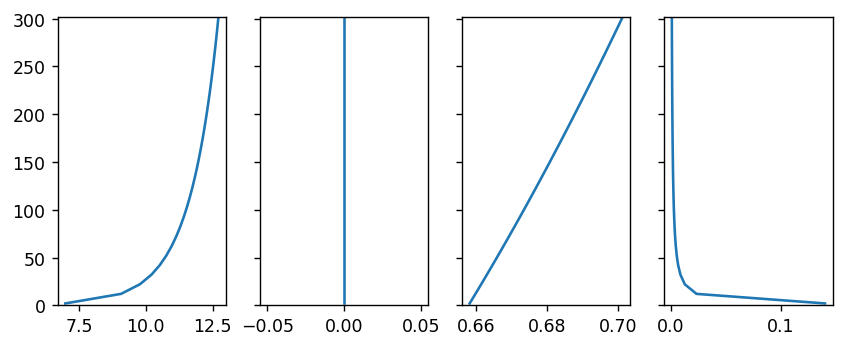

In [8]:
fig, axs = plt.subplots(1,4, sharey=True, dpi=125, figsize=(8,3))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Vinit[Ny//2,:], zvec)
axs[2].plot(Kinit[Ny//2,:], zvec)
axs[3].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [9]:
xvecplot=[0, 200, 400, 1000, 1200] #600, 1000]
dx  = 50 #150

xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec=[0, 200, 400, 600]

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, 
                             SANDwake3D.getTypicalWMBC(Uinit[0,-1], params['Tw'], veerBC=Vprof),
                             SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=1, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = 50.0 dx = 50.0
ZLO_WALLBC: {'ustar': 0.31536701368298814, 'Lnext': -28460.677381234433, 'Tstar': -0.0002592001008120066}
C3eps_use: 1.7637960052349528
avg_dil: 0.0003331214680434475
x = 100.0 dx = 50.0
ZLO_WALLBC: {'ustar': 0.4729290791328578, 'Lnext': -98312.83982274917, 'Tstar': -0.0001772062183887179}
C3eps_use: 1.7646514349466873
avg_dil: 0.00032530410361675504
x = 150.0 dx = 50.0
ZLO_WALLBC: {'ustar': 0.43135778182636964, 'Lnext': -74340.61000831198, 'Tstar': -0.00019331384240903768}
C3eps_use: 1.7645390383692854
avg_dil: 8.547529371733603e-05
x = 200.0 dx = 50.0
ZLO_WALLBC: {'ustar': 0.4400368755864112, 'Lnext': -79071.55828039965, 'Tstar': -0.00019001519964418592}
C3eps_use: 1.7645666174885266
avg_dil: 2.124725595391819e-05
x = 250.0 dx = 50.0
ZLO_WALLBC: {'ustar': 0.4328481595922352, 'Lnext': -75270.86874192419, 'Tstar': -0.00019321437574636413}
C3eps_use: 1.764544735139444
avg_dil: 1.7596285841245908e-05
x = 300.0 dx = 50.0
ZLO_WALLBC: {'ustar': 0.43076566374548003, 'Lnext

(2.0, 302.0)

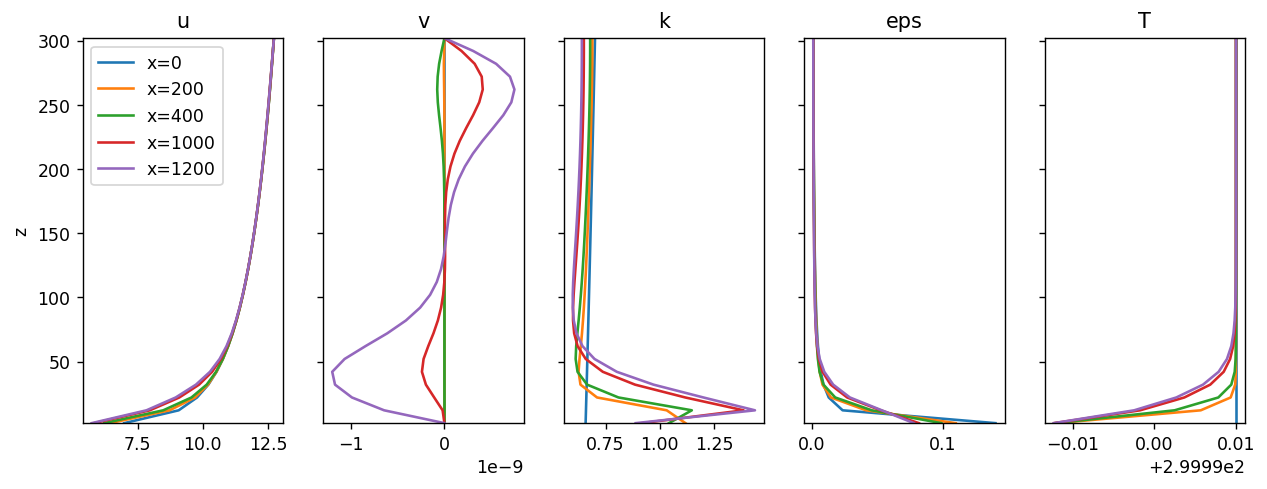

In [10]:
plotvars=['u', 'v', 'k', 'eps', 'T']
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()
islice = find_nearest(yvec, 0)# Ny//2

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,4), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

## Plot LES data

In [11]:
def plotrotorlinesax(ax, zhh, rotorD, xstart, xend, **kwargs):
    ax.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) # Plot the HH line
    ax.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line
    ax.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line   

In [12]:
baseurl      = 'https://raw.githubusercontent.com/Exawind/exawind-benchmarks/refs/heads/main/amr-wind/' + \
               '/atmospheric_boundary_layer/convective_abl_nrel5mw/results/'
AMR_WS_url   = urllib.request.urlopen(baseurl+'/avgprofile_5000s_Uhoriz.csv') 
AMR_WS       = np.loadtxt(AMR_WS_url, delimiter=',',skiprows=1)
AMR_WD_url   = urllib.request.urlopen(baseurl+'/avgprofile_5000s_WindDir.csv') 
AMR_WD       = np.loadtxt(AMR_WD_url, delimiter=',',skiprows=1)

Text(0.5, 0, 'Veer [deg]')

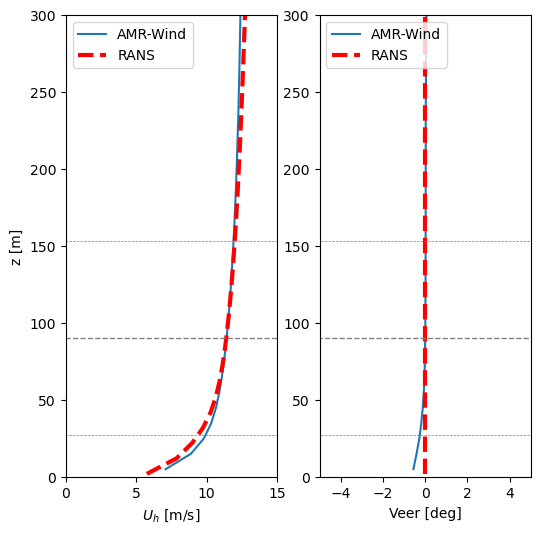

In [16]:
iRANS = -1
fig, axs = plt.subplots(1,2, figsize=(6,6))
axs[0].plot(AMR_WS[:,1], AMR_WS[:,0], label='AMR-Wind')
Uh = np.sqrt(phi['u'][iRANS,islice,:]**2 + phi['v'][iRANS,islice,:]**2)
axs[0].plot(Uh, zvec, 'r--', lw=3, label='RANS')
axs[0].set_xlim([0, 15])

z  = AMR_WD[:,0]
WD = AMR_WD[:,1]
thetahh = np.interp(turbhh, z, WD)
axs[1].plot(WD-thetahh, z, label='AMR-Wind')

WD_RANS = np.arctan2(phi['v'][iRANS,islice,:], phi['u'][iRANS,islice,:])*180/np.pi
axs[1].plot(WD_RANS, zvec, 'r--', lw=3, label='RANS')
axs[1].set_xlim([-5, 5])

for ax in axs:
    ax.set_ylim([0,300])
    ax.legend(loc='upper left')
    # Plot the turbine dimensions
    plotrotorlinesax(ax, turbhh, rotorD, -10, 20, linestyles='dashed', color='gray',)
    
ax=axs[0]
ax.set_xlabel('$U_h$ [m/s]')
ax.set_ylabel('z [m]')
ax=axs[1]
ax.set_xlabel('Veer [deg]')